In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lthnhthngt/cs221-weight --unzip

Dataset URL: https://www.kaggle.com/datasets/lthnhthngt/cs221-weight
License(s): unknown
100% 5.71G/5.71G [01:06<00:00, 92.9MB/s]



In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# =============================================================================
# 1. CẤU HÌNH (THAY ĐỔI TẠI ĐÂY)
# =============================================================================
CHECKPOINT_PATH = "/content/checkpoints/checkpoints/final_model" # Hoặc đường dẫn checkpoint ví dụ: "checkpoint-500"
TEST_FILE_PATH = "/content/test_clean.csv"

CONFIG = {
    "text_col": "text",
    "label_col": "label",
    "class_names": ["Normal", "Depression", "Suicidal", "Anxiety"],
    "max_seq_length": 300,
    "batch_size": 32,
}

CONFIG["id2label"] = {i: label for i, label in enumerate(CONFIG["class_names"])}
CONFIG["label2id"] = {label: i for i, label in enumerate(CONFIG["class_names"])}

# =============================================================================
# 2. ĐỊNH NGHĨA DATASET (Giống file train)
# =============================================================================
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        tokenizer.truncation_side = 'right'
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_token_type_ids=True,
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

def load_test_data(path, cfg):
    df = pd.read_csv(path).dropna(subset=[cfg["text_col"], cfg["label_col"]])
    texts = df[cfg["text_col"]].astype(str).tolist()
    labels = df[cfg["label_col"]].map(cfg["label2id"]).astype(int).tolist()
    return texts, labels

In [ ]:
# =============================================================================
# 3. LOAD MODEL & TOKENIZER
# =============================================================================
print(f"--- Đang load model từ: {CHECKPOINT_PATH} ---")

# Load tokenizer từ thư mục checkpoint
tokenizer = BertTokenizerFast.from_pretrained(CHECKPOINT_PATH)

# Load model
model = BertForSequenceClassification.from_pretrained(CHECKPOINT_PATH)

--- Đang load model từ: /content/checkpoints/checkpoints/final_model ---


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# =============================================================================
# 4. CHUẨN BỊ DỮ LIỆU TEST
# =============================================================================
test_texts, test_labels = load_test_data(TEST_FILE_PATH, CONFIG)
test_dataset = MentalHealthDataset(test_texts, test_labels, tokenizer, CONFIG["max_seq_length"])

# Sử dụng Trainer của HF để chạy inference cho nhanh và tối ưu
training_args = TrainingArguments(
    output_dir="./temp_eval",
    per_device_eval_batch_size=CONFIG["batch_size"],
    fp16=True if torch.cuda.is_available() else False,
    report_to="none"
)

trainer = Trainer(model=model, args=training_args)

--- Đang dự đoán trên tập test... ---



==================== KẾT QUẢ TRÊN TẬP TEST ====================
              precision    recall  f1-score   support

      Normal     0.9576    0.9541    0.9558      2723
  Depression     0.8056    0.7560    0.7800      2176
    Suicidal     0.7406    0.8125    0.7749      1680
     Anxiety     0.8898    0.8696    0.8796       836

    accuracy                         0.8543      7415
   macro avg     0.8484    0.8480    0.8476      7415
weighted avg     0.8562    0.8543    0.8547      7415



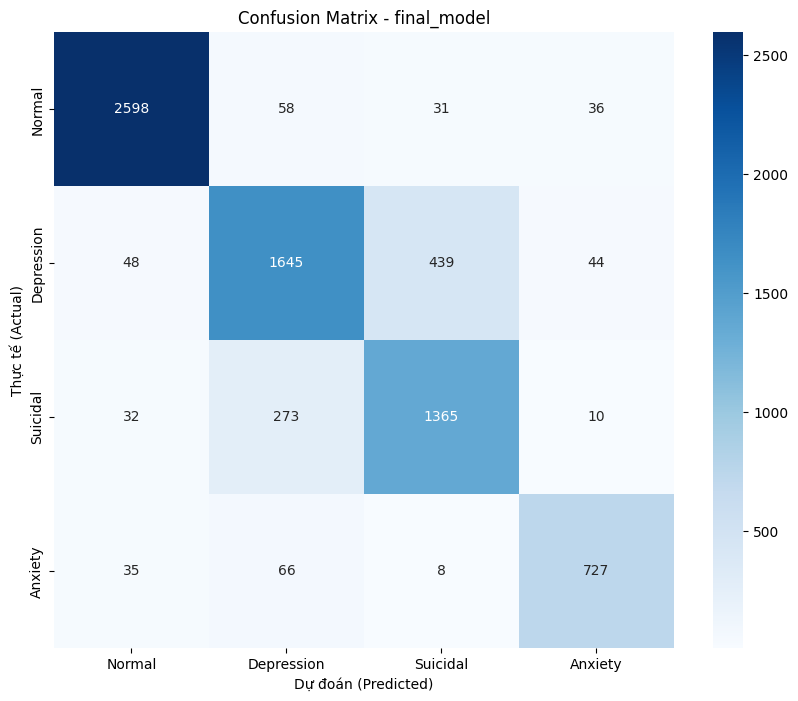

In [ ]:
# =============================================================================
# 5. CHẠY INFERENCE & IN BÁO CÁO
# =============================================================================
print("--- Đang dự đoán trên tập test... ---")
predictions = trainer.predict(test_dataset)

y_preds = np.argmax(predictions.predictions, axis=-1)
y_true = np.array(test_labels)

# In Classification Report
print("\n" + "="*20 + " KẾT QUẢ TRÊN TẬP TEST " + "="*20)
report = classification_report(
    y_true,
    y_preds,
    target_names=CONFIG["class_names"],
    digits=4
)
print(report)

# Vẽ Confusion Matrix (Tùy chọn)
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CONFIG["class_names"],
    yticklabels=CONFIG["class_names"]
)
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title(f'Confusion Matrix - {os.path.basename(CHECKPOINT_PATH)}')
plt.show()